# 06 Single CNN Trial (EEGNet Baseline)

This notebook runs one baseline CNN model (EEGNet) on subject-level Welch PSD features.
It is a Phase 2 trial notebook and does not modify Phase 1 outputs.

In [1]:
import sys, torch
print(sys.executable)
print(torch.__version__)


d:\2026 MTECH Project\alz_project\.venv\Scripts\python.exe
2.11.0+cpu


In [2]:
%matplotlib inline
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from eegnet_baseline import EEGNetConfig, train_eegnet_baseline


In [3]:
try:
    import torch  # noqa: F401
    print('PyTorch detected. Ready to train EEGNet.')
except Exception:
    raise RuntimeError('PyTorch is not installed. Run: pip install torch')


PyTorch detected. Ready to train EEGNet.


In [4]:
summary_csv_non_overlap = PROJECT_ROOT / 'data' / 'metadata' / 'psd_feature_summary.csv'
summary_csv_overlap50 = PROJECT_ROOT / 'data' / 'metadata' / 'psd_feature_summary_overlap50.csv'

summary_non_overlap_df = pd.read_csv(summary_csv_non_overlap)
summary_overlap50_df = pd.read_csv(summary_csv_overlap50)

print('Non-overlap summary rows:', len(summary_non_overlap_df))
print('Overlap-50 summary rows:', len(summary_overlap50_df))

summary_non_overlap_df.head()


Non-overlap summary rows: 88
Overlap-50 summary rows: 88


,subject_id,class_name,label,n_epochs,n_channels,n_freq_bins,output_file
0,sub-001,AD,0,138,19,89,data\processed\psd_features\sub-001_psd_featur...
1,sub-002,AD,0,180,19,89,data\processed\psd_features\sub-002_psd_featur...
2,sub-003,AD,0,76,19,89,data\processed\psd_features\sub-003_psd_featur...
3,sub-004,AD,0,143,19,89,data\processed\psd_features\sub-004_psd_featur...
4,sub-005,AD,0,151,19,89,data\processed\psd_features\sub-005_psd_featur...


In [5]:
cfg = EEGNetConfig(
    epochs=20,
    batch_size=8,
    learning_rate=1e-3,
    test_size=0.2,
    random_state=42,
)

metrics_non_overlap = train_eegnet_baseline(summary_csv_non_overlap, cfg=cfg)
metrics_overlap50 = train_eegnet_baseline(summary_csv_overlap50, cfg=cfg)

comparison_df = pd.DataFrame([
    {'setting': 'non_overlap_0pct', **metrics_non_overlap},
    {'setting': 'overlap_50pct', **metrics_overlap50},
])

comparison_df


,setting,n_subjects,n_classes,train_accuracy,test_accuracy
0,non_overlap_0pct,88.0,3.0,0.571429,0.5
1,overlap_50pct,88.0,3.0,0.685714,0.5


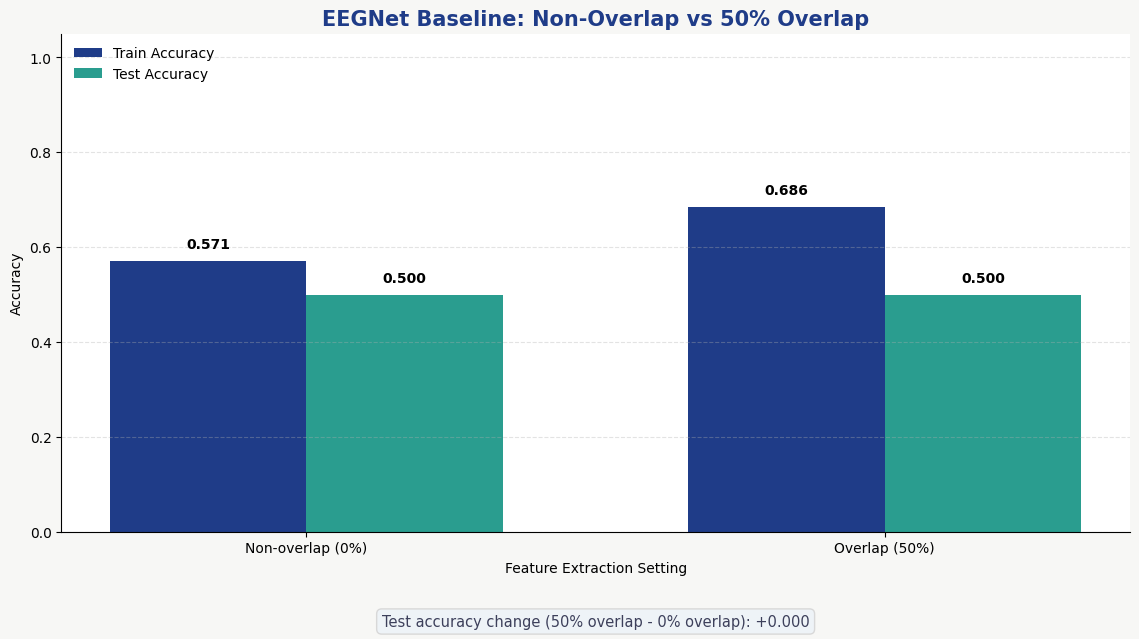

In [6]:
# Presentation-ready comparison plot
fig, ax = plt.subplots(figsize=(11.5, 6.5))
fig.patch.set_facecolor('#f7f7f5')
ax.set_facecolor('white')

settings = comparison_df['setting'].tolist()
train_vals = comparison_df['train_accuracy'].astype(float).values
test_vals = comparison_df['test_accuracy'].astype(float).values

x = np.arange(len(settings))
width = 0.34

train_bars = ax.bar(x - width/2, train_vals, width=width, color='#1f3c88', label='Train Accuracy')
test_bars = ax.bar(x + width/2, test_vals, width=width, color='#2a9d8f', label='Test Accuracy')

ax.set_title('EEGNet Baseline: Non-Overlap vs 50% Overlap', fontsize=15, fontweight='bold', color='#1f3c88')
ax.set_xlabel('Feature Extraction Setting')
ax.set_ylabel('Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(['Non-overlap (0%)', 'Overlap (50%)'])
ax.set_ylim(0, 1.05)
ax.grid(True, axis='y', linestyle='--', alpha=0.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='upper left')

for bars in [train_bars, test_bars]:
    for b in bars:
        v = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Improvement annotation based on test accuracy
delta_test = test_vals[1] - test_vals[0]
improve_txt = f"Test accuracy change (50% overlap - 0% overlap): {delta_test:+.3f}"
ax.text(0.5, -0.18, improve_txt, transform=ax.transAxes, ha='center', va='center', fontsize=10.5,
        color='#3d405b', bbox=dict(boxstyle='round,pad=0.35', facecolor='#eef3f7', edgecolor='#d8d8d8'))

plt.tight_layout()
fig.savefig(PROJECT_ROOT / 'results' / 'figures' / '10_eegnet_accuracy_bar_comparison.png', dpi=220, bbox_inches='tight')
plt.show()


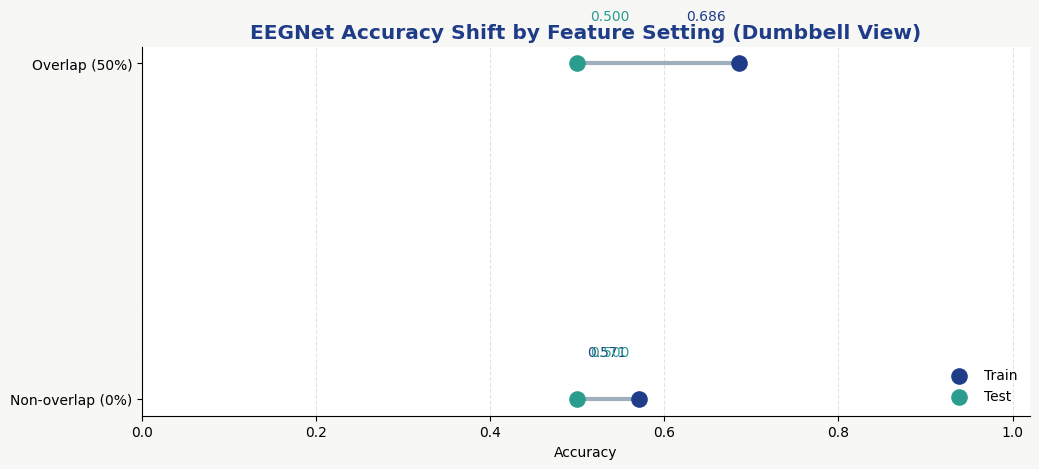

In [7]:
# Optional publication-style chart: dumbbell comparison (Test Accuracy)
fig, ax = plt.subplots(figsize=(10.5, 4.8))
fig.patch.set_facecolor('#f7f7f5')
ax.set_facecolor('white')

labels = ['Non-overlap (0%)', 'Overlap (50%)']
y = np.arange(len(labels))
train_vals = comparison_df['train_accuracy'].astype(float).values
test_vals = comparison_df['test_accuracy'].astype(float).values

for i in range(len(labels)):
    ax.plot([train_vals[i], test_vals[i]], [y[i], y[i]], color='#8da0ae', lw=3, alpha=0.85)

ax.scatter(train_vals, y, s=120, color='#1f3c88', label='Train', zorder=3)
ax.scatter(test_vals, y, s=120, color='#2a9d8f', label='Test', zorder=3)

for i in range(len(labels)):
    ax.text(train_vals[i] - 0.015, y[i] + 0.12, f"{train_vals[i]:.3f}", color='#1f3c88', fontsize=10, ha='right', va='bottom')
    ax.text(test_vals[i] + 0.015, y[i] + 0.12, f"{test_vals[i]:.3f}", color='#2a9d8f', fontsize=10, ha='left', va='bottom')

ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlim(0, 1.02)
ax.set_xlabel('Accuracy')
ax.set_title('EEGNet Accuracy Shift by Feature Setting (Dumbbell View)', fontsize=14.5, fontweight='bold', color='#1f3c88')
ax.grid(True, axis='x', linestyle='--', alpha=0.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='lower right')

plt.tight_layout()
fig.savefig(PROJECT_ROOT / 'results' / 'figures' / '11_eegnet_accuracy_dumbbell_comparison.png', dpi=220, bbox_inches='tight')
plt.show()


## Notes
- This notebook now trains one EEGNet baseline on both feature settings: non-overlap and 50% overlap.
- Use the resulting comparison table as an initial feasibility check, not final thesis performance.
- Final model comparison should use your planned subject-wise and group-aware validation protocol.
